## 0. Imports & Configuration

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [39]:
path = '..\\data\\segment_alerts_all_airports_train.csv'
df = pd.read_csv(path)
print(f'Shape : {df.shape}')
IDS = ['lightning_id','lightning_airport_id','date','lon','lat','airport','airport_alert_id']
df.head()

Shape : (507071, 13)


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [40]:
import matplotlib.gridspec as gridspec
def desc_stats(col):
    s = df[col]
    n_total = len(s)
    n_missing = s.isna().sum()
    pct_missing = n_missing / n_total * 100
    
    print(f"=== {col} ===")
    print(f"Manquants     : {n_missing} ({pct_missing:.2f}%)")
    print()
    print(s.describe().to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(col, fontsize=13)
    
    # Histogramme + KDE
    s.dropna().plot.hist(ax=axes[0], bins=50, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribution")
    axes[0].set_xlabel(col)
    
    # Boxplot
    s.dropna().plot.box(ax=axes[1], color="steelblue")
    axes[1].set_title("Boxplot")
    
    # Barre missings
    if n_missing > 0:
        for ax in axes:
            ax.set_xlabel(f"{ax.get_xlabel()}\n({pct_missing:.1f}% manquants)")
    
    plt.tight_layout()
    plt.show()


In [41]:
# 2.1 — Types & parsing
VAR = ['dist','azimuth']
df['date'] = pd.to_datetime(df['date'], utc=True)
df['icloud'] = df['icloud'].astype(bool)
df['is_last_lightning_cloud_ground'] = df['is_last_lightning_cloud_ground'].astype('boolean')

# 2.2 — Variables temporelles
df['year']   = df['date'].dt.year
df['month']  = df['date'].dt.month
df['hour']   = df['date'].dt.hour
df['season'] = df['month'].map({
    12:'Hiver', 1:'Hiver', 2:'Hiver',
    3:'Printemps', 4:'Printemps', 5:'Printemps',
    6:'Été', 7:'Été', 8:'Été',
    9:'Automne', 10:'Automne', 11:'Automne'
})
df = df.sort_values(["airport", "date"])
VAR += ['month','hour']
# index reset
df = df.reset_index(drop=True)
# 2.3 — Alerte Pise 2016 (données intra-nuage potentiellement biaisées)
mask_pise_2016 = (df['airport'] == 'Pise') & (df['year'] == 2016) & (df['icloud'] == True)
print(f"⚠️  Éclairs intra-nuage Pise 2016 : {mask_pise_2016.sum()} (à exclure si analyse icloud)")
df_clean = df#.copy()#[~mask_pise_2016]

# 2.4 — Sous-ensembles utiles
df_20km  = df_clean[df_clean['dist'] <= 20].copy()   # zone opérationnelle
df_cg    = df_clean[df_clean['icloud'] == False].copy()  # éclairs nuage-sol uniquement
df_cg_20 = df_cg[df_cg['dist'] <= 20].copy()

print(f"\nDataset nettoyé     : {df_clean.shape[0]:,} éclairs")
print(f"Éclairs ≤ 20 km     : {df_20km.shape[0]:,}")
print(f"Éclairs nuage-sol   : {df_cg.shape[0]:,}")
print(f"CG ≤ 20 km          : {df_cg_20.shape[0]:,}")

⚠️  Éclairs intra-nuage Pise 2016 : 19404 (à exclure si analyse icloud)

Dataset nettoyé     : 507,071 éclairs
Éclairs ≤ 20 km     : 220,498
Éclairs nuage-sol   : 128,992
CG ≤ 20 km          : 56,599


## Temps depuis les derniers éclairs

In [42]:
# temps depuis le dernier éclair (tous types)
df["time_since_last_lightning"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)


# temps depuis le dernier éclair nuage-sol
df["date_cg"] = df["date"].where(df["icloud"] == False)

df["time_since_last_cloud_ground"] = (
    df.groupby("airport")["date_cg"]
    .ffill()
)

df["time_since_last_cloud_ground"] = (
    df["date"] - df["time_since_last_cloud_ground"]
).dt.total_seconds()



# temps depuis le dernier éclair intra-nuage
df["date_ic"] = df["date"].where(df["icloud"] == True)

df["time_since_last_intra_cloud"] = (
    df.groupby("airport")["date_ic"]
    .ffill()
)

df["time_since_last_intra_cloud"] = (
    df["date"] - df["time_since_last_intra_cloud"]
).dt.total_seconds()
###########################################################################
df["time_since_last_lightning"] = df["time_since_last_lightning"].fillna(0)
lightning_mask = df["time_since_last_lightning"]>=3600
df["time_since_last_intra_cloud"] = df["time_since_last_intra_cloud"].fillna(0)
df["time_since_last_cloud_ground"] = df["time_since_last_cloud_ground"].fillna(0)


In [43]:
# Censurer les durées au delà d un seuil, fixé ici à 1h
###########################################################################################
df["time_since_last_cloud_ground2"] = np.log(df["time_since_last_cloud_ground"].clip(0,3600)+1)
df["time_since_last_intra_cloud2"]= np.log(df["time_since_last_intra_cloud"].clip(0,3600).fillna(0)+1)
df["time_since_last_lightning2"] = np.log(df["time_since_last_lightning"].clip(0,3600).fillna(0)+1)
VAR.append("time_since_last_lightning2")
VAR.append("time_since_last_intra_cloud2")
VAR.append("time_since_last_cloud_ground2")


In [44]:
# col = "dist"
# #df[col] = df[col].fillna(0)
# desc_stats(col)

## Nombre d’éclairs récents (fenêtres temporelles)

In [45]:
df = df.set_index("date")

# nombre d'éclairs dans différentes fenêtres
for window in ["1min", "5min", "10min", "20min", "30min"]:
    
    df[f"count_{window}"] =(
        df.groupby("airport")["lightning_id"]
        .rolling(window)
        .count()
        .reset_index(level=0, drop=True)
    )
    df[f"log_count_{window}"] =  np.log(df[f"count_{window}"]+1)
    VAR.append(f"log_count_{window}")

## Comptage par type d’éclair

In [46]:
# éclairs nuage-sol
df["cg"] = (df["icloud"] == False).astype(int)
# éclairs intra-nuage
df["ic"] = (df["icloud"] == True).astype(int)

for window in ["5min", "10min", "20min"]:
    df[f"ic_count_{window}"] = (
        df.groupby("airport")["ic"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"cg_count_{window}"] = (
        df.groupby("airport")["cg"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"log_ic_count_{window}"] = np.log(df[f"ic_count_{window}"]+1)
    df[f"log_cg_count_{window}"] = np.log(df[f"cg_count_{window}"]+1)
    VAR+=[f"log_ic_count_{window}", f"log_cg_count_{window}"]

=== log_ic_count_10min ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          4.229013
std           1.640422
min           0.000000
25%           3.218876
50%           4.543295
75%           5.521461
max           7.331060


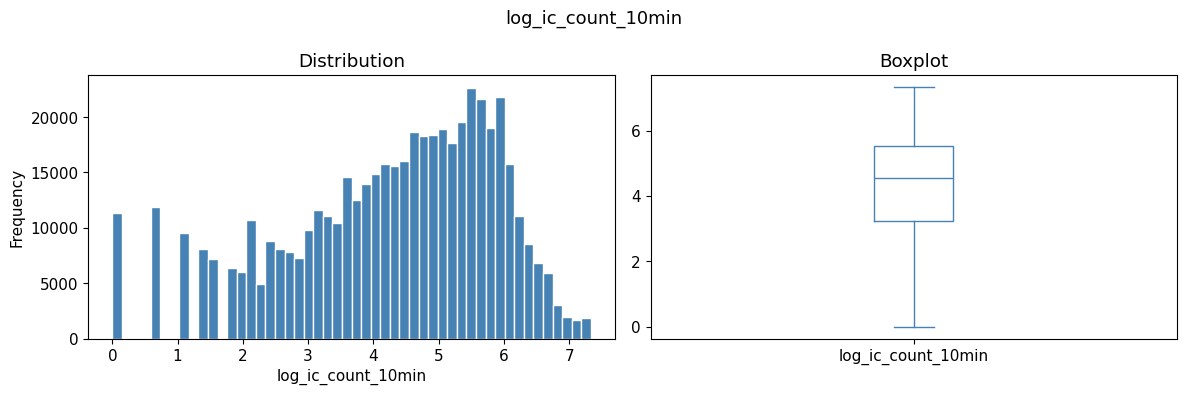

In [47]:
col = "log_ic_count_10min"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Taux d'activité

In [48]:
df["rate_1min"] = df["count_1min"]
df["rate_5min"] = df["count_5min"] / 5
df["rate_10min"] = df["count_10min"] / 10

df["rate_trend"] = np.log(df["count_10min"] - df["count_5min"]+1)

df["activity_decay"] = df["rate_5min"] / (df["rate_10min"] + 1e-6)

VAR+=["rate_trend","activity_decay"]

## Variable spatiale

In [49]:
for window in ["1min", "5min", "10min"]:
    
    df[f"mean_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    df[f"min_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .min()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_dist_{window}",f"min_dist_{window}"] 

df["distance_trend"] = df["mean_dist_1min"] - df["mean_dist_10min"]
#dispersion spatiale

df["std_lat_10min"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

df["std_lon_10min"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

VAR+=["distance_trend","std_lat_10min","std_lon_10min","azimuth_change"]
#direction du front orageux
# les NA dans std_azimuth_ sont dus à une absence de valeurs dans la fenetre emporelle
# l imputation par 0 prends tout son sens
###################################################################
df["std_lon_10min"] = df["std_lon_10min"].fillna(0)
df["std_lat_10min"] = df["std_lat_10min"].fillna(0)
for window in ["1min", "10min"]:
    df[f"mean_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"std_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )
    df[f"std_azimuth_{window}"] = df[f"std_azimuth_{window}"].fillna(0)
    VAR+=[f"mean_azimuth_{window}",f"std_azimuth_{window}"]

df["azimuth_change"] = df["mean_azimuth_1min"] - df["mean_azimuth_10min"]

=== azimuth_change ===
Manquants     : 0 (0.00%)

count    507071.000000
mean         -3.363007
std          28.811422
min        -314.727072
25%         -11.150848
50%          -1.535720
75%           5.863439
max         308.090097


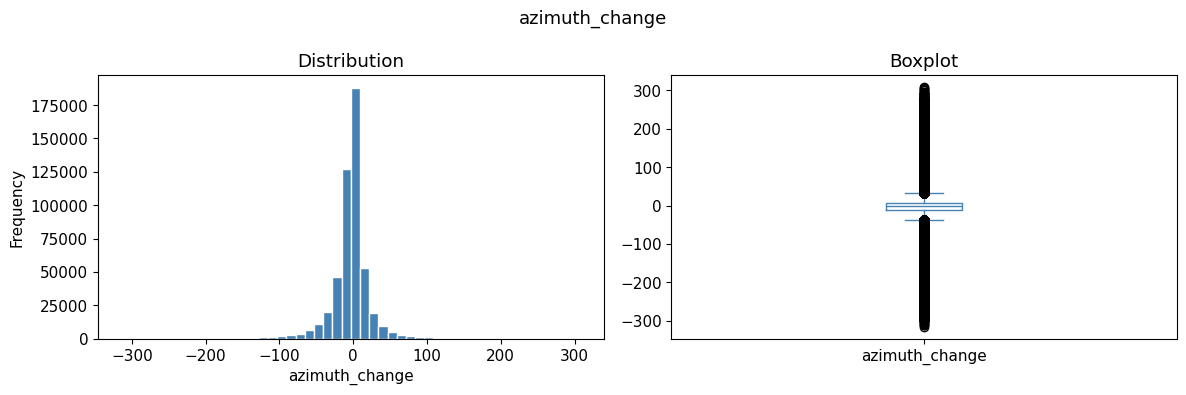

In [50]:
col = "azimuth_change"
desc_stats(col)

## intensité électrique

In [51]:
for window in ["1min", "10min"]:
    df[f"mean_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"max_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .max()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_amplitude_{window}",f"max_amplitude_{window}"]

df["amplitude_change"] = df["mean_amplitude_1min"] - df["mean_amplitude_10min"]

df["std_amplitude_10min"] = (
    df.groupby("airport")["amplitude"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)
###################################################################
df["log_std_amplitude_10min"] = np.log(df["std_amplitude_10min"].fillna(0)+1)
VAR+=["amplitude_change","log_std_amplitude_10min"]

## Durée d alerte

In [52]:
#ratio nuage-sol
df["cg_ratio"] = df["cg_count_10min"] / (df["count_10min"] + 1e-6)
#burst d’éclairs
df["burst_indicator"] = (df["count_1min"] > 5).astype(int)
df["date"] = pd.to_datetime(df.index, utc=True)
#durée d'alerte
df["alert_start"] = (
    df.groupby(["airport", "airport_alert_id"])["date"]
    .transform("min")
)


df["alert_duration"] = (
    df.index - df["alert_start"]
).dt.total_seconds()
#########################################################
df["alert_duration"] = df["alert_duration"].fillna(0).clip(0,3600)
#df = df.reset_index()
VAR+= ["cg_ratio","burst_indicator","alert_duration"]

## Vitesse de déplacement de l’orage

In [53]:
# différence temporelle entre éclairs
df["delta_t"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)

# déplacement spatial approximatif
df["delta_dist"] = df.groupby("airport")["dist"].diff()

# vitesse radiale (km/sec)
df["storm_velocity"] = df["delta_dist"] / (df["delta_t"] + 1e-6)

VAR+=["delta_dist","storm_velocity"]
# par soucis de coherence, pour des éclairs avec plus d une heure d écart, la variation de distance passera à 0
bol = df["time_since_last_lightning"]>=3600
df.loc[bol,["delta_dist","storm_velocity"]] = 0
df.loc[:,["delta_dist","storm_velocity"]] = df.loc[:,["delta_dist","storm_velocity"]].fillna(0)

## Accélération de l’activité électrique

In [54]:
# variation du taux d'activité
df["activity_acceleration"] = (
    df["rate_1min"] - df["rate_5min"]
)
# df["activity_trend"] = (
#     df["count_10min"]- df["count_5min"]
# )
VAR+=["activity_acceleration"]

=== activity_acceleration ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          0.963427
std           5.275369
min         -45.400000
25%          -1.000000
50%           0.800000
75%           2.800000
max          68.800000


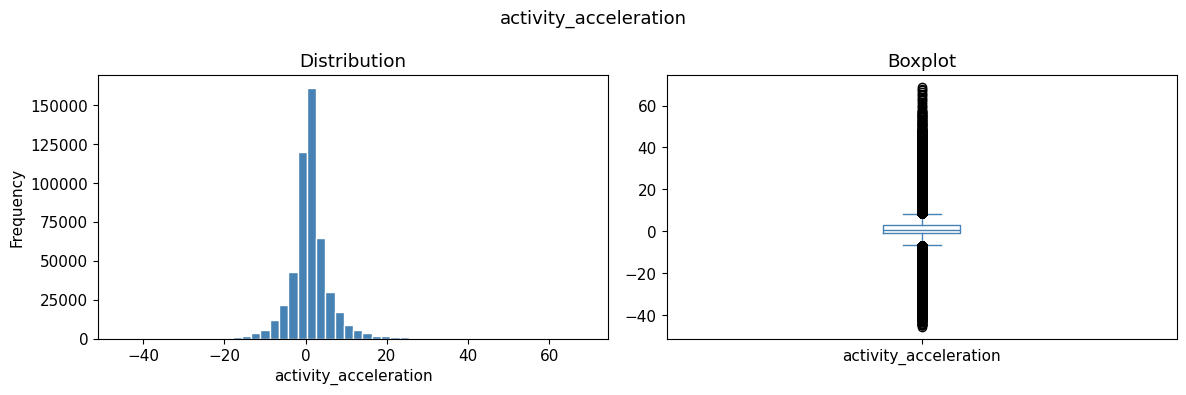

In [55]:
col = "activity_acceleration"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Silence time

In [56]:
# indicateurs de silence prolongé
df["silence_30min"] = (df["time_since_last_lightning"] > 1800).astype(int)
VAR+=["silence_30min"]


## direction du déplacement

In [57]:
df["azimuth_diff"] = df.groupby("airport")["azimuth"].diff()
######################################################
df["azimuth_diff"] = df["azimuth_diff"].fillna(0)
lightning_mask = df['time_since_last_lightning']>=3600
df.loc[lightning_mask,'azimuth_diff'] = 0
df["storm_direction_change"] = np.log(df["azimuth_diff"].abs()+1)
VAR+=["azimuth_diff","storm_direction_change"]

## Distance du centre de l’orage à l’aéroport

In [58]:
# centre de masse des éclairs dans les 10 dernières minutes

df["storm_lat_center"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

df["storm_lon_center"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

# récupérer coordonnées
df["airport_lat"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][0])
df["airport_lon"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][1])

# distance euclidienne simple (approximation locale)

df["storm_center_distance"] = np.sqrt(
    (df["storm_lat_center"] - df["airport_lat"])**2 +
    (df["storm_lon_center"] - df["airport_lon"])**2
)

# déplacement du centre
df["storm_center_move"] = (
    df.groupby("airport")["storm_center_distance"]
    .diff()
)
#########################################
df["storm_center_move"] = df["storm_center_move"].fillna(0)
df.loc[lightning_mask,"storm_center_move"] = 0
# vitesse (distance / temps)

df["storm_center_velocity"] = (
    df["storm_center_move"] /(
    df["time_since_last_lightning"] + 1)
)
df["storm_spread"] = (
    df["std_lat_10min"] + df["std_lon_10min"]
)
VAR+=["storm_center_velocity","storm_spread","storm_center_distance","storm_center_move"]

# Création de la target : temps jusqu’au prochain éclair

In [59]:
# éclair nuage-sol
df["is_cloud_ground"] = 1*(df["icloud"] == False)

# 1️⃣ identifier les éclairs cloud-ground dans 20 km
df["cg_20km"] = (
    (~df["icloud"]) &
    (df["dist"] <= 20)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg20_date"] = df["date"].where(df["cg_20km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg20_date"] = (
    df.groupby("airport")["cg20_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg20"] = (
    df["next_cg20_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg20"]  = df["time_to_next_cg20"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg20"].notna()]


VAR+=["is_cloud_ground","cg_20km"]
TARGET = ["time_to_next_cg20"]


In [60]:
# Transformation logarithmique
df["target_log_time"] = np.log(df["time_to_next_cg20"]+1)# np.log1p(df["time_to_next_cg20"])# pred_time = np.expm1(pred_log)

# Transformation par classes temporelles
bins = [0, 300, 600, 1200, 1800, np.inf] # en secondes

labels = [0,1,2,3,4]

df["target_bins"] = pd.cut(
    df["time_to_next_cg20"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
TARGET+=["target_log_time","target_bins"]

=== target_log_time ===
Manquants     : 0 (0.00%)

count    507034.000000
mean          3.724461
std           2.463647
min           0.000000
25%           1.945910
50%           3.583519
75%           5.451038
max           8.188967


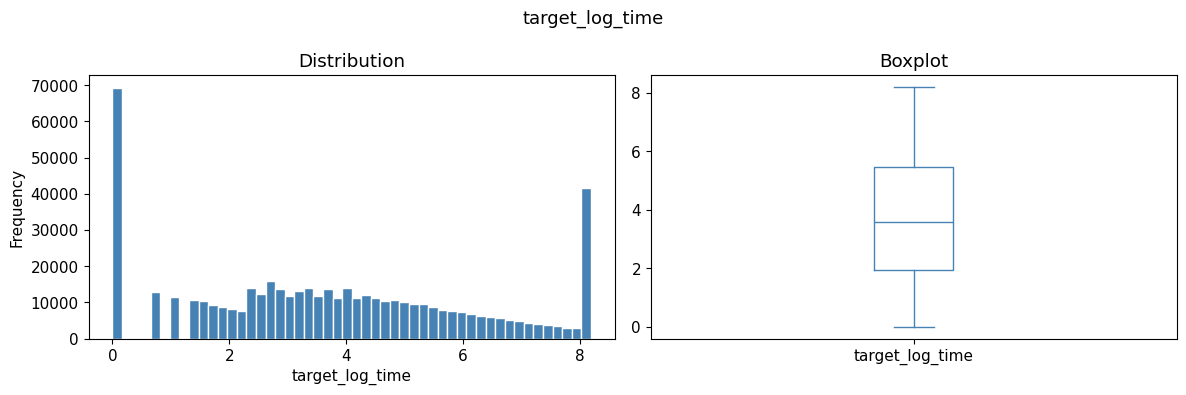

In [61]:
col = "target_log_time"
#df[col] = df[col].fillna(0)
desc_stats(col)

# Split temporel

In [62]:
print(df["date"].min())
print(df["date"].max())

2016-01-02 01:10:41+00:00
2022-12-16 13:17:59+00:00


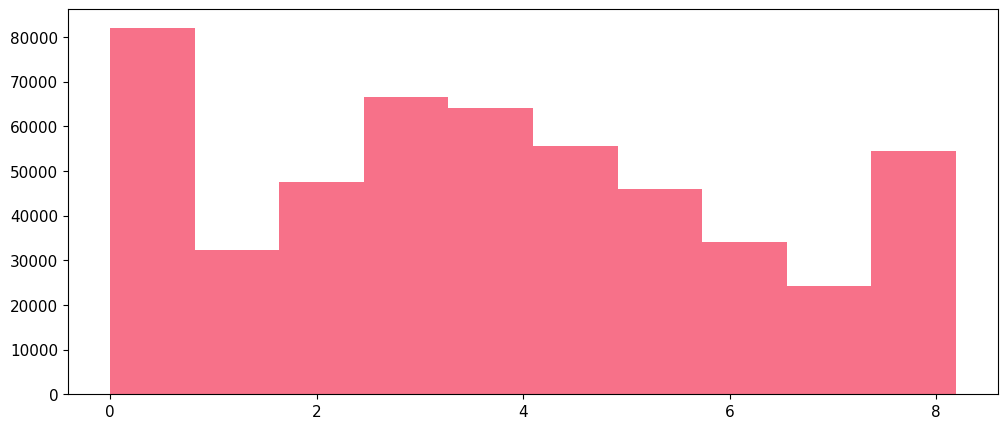

In [63]:
plt.hist(df["target_log_time"])
plt.show()

In [64]:
new = ['season_Automne','season_Hiver','season_Printemps',
        'airport_Ajaccio','airport_Pise','airport_Bastia',
        'airport_Biarritz','airport_Nantes'
        ]
df2 = pd.get_dummies(df)
features = list(set(VAR))
#df2[features] = df2[features].fillna(0)
features += new
df2[new] = df2[new]*1


# train

train = df2[df2["year"] <= 2020]

# validation
val = df2[df2["year"] == 2021]

# test
test = df2[df2["year"] >= 2022]

print("train :",train["date"].min(), train["date"].max())
print("val :",val["date"].min(), val["date"].max())
print("test :",test["date"].min(), test["date"].max())

print(len(features))
X_train = train[features]
y_train = train["target_log_time"]

X_val = val[features]
y_val = val["target_log_time"]

X_test = test[features]
y_test = test["target_log_time"]


train : 2016-01-02 01:10:41+00:00 2020-12-31 23:19:36+00:00
val : 2021-01-01 00:06:55+00:00 2021-12-27 15:12:35+00:00
test : 2022-01-05 13:32:40+00:00 2022-12-16 13:17:59+00:00
63


# Missings?

In [66]:
mis = df2[features].isna().sum()
col_mis = [c for c in mis.index if mis[c]>0]
mis[col_mis]

Series([], dtype: int64)

# Feature selection

In [67]:
from scipy.stats import spearmanr
from tqdm import tqdm
def select_features_spearman(df,feature_cols, target_col, threshold_redundancy=0.85, verbose=True):
    """
    Sélectionne les features par corrélation de Spearman avec la cible,
    puis élimine les redondances entre features sélectionnées.
    
    Args:
        df               : DataFrame avec features et cible
        target_col       : nom de la colonne cible
        threshold_redundancy : seuil de corrélation inter-features (défaut 0.85)
        verbose          : afficher les étapes
    
    Returns:
        selected_features : liste ordonnée des features retenues
        df_results        : DataFrame complet des corrélations
    """
    
    y = df[target_col]
    
    # ── Étape 1 : Corrélation de chaque feature avec la cible ─────────────
    if verbose:
        print("=" * 60)
        print("ÉTAPE 1 — Corrélation Spearman avec la cible")
        print("=" * 60)
    
    results = []

    for col in tqdm(feature_cols):
        # Aligner explicitement sur les index communs APRÈS dropna des deux séries
        idx_common = df[col].dropna().index.intersection(y.dropna().index)
        
        if len(idx_common) < 30:
            if verbose:
                print(f"  ⚠️  {col} : pas assez d'observations ({len(idx_common)}), ignorée")
            continue
        
        # Forcer la conversion en array numpy pour éviter tout problème d'index
        x_arr = df.loc[idx_common, col].to_numpy()
        y_arr = y.loc[idx_common].to_numpy()
        
        rho, pval = spearmanr(x_arr, y_arr)
        results.append({'feature': col, 'rho': rho, 'abs_rho': abs(rho), 'pval': pval})
    
    df_results = (
        pd.DataFrame(results)
        .sort_values('abs_rho', ascending=False)
        .reset_index(drop=True)
    )
    
    if verbose:
        print(f"\n{'Rang':<5} {'Feature':<35} {'Rho':>8} {'|Rho|':>8} {'p-value':>12}")
        print("-" * 70)
        for i, row in df_results.iterrows():
            sig = "***" if row['pval'] < 0.001 else "**" if row['pval'] < 0.01 else "*" if row['pval'] < 0.05 else "ns"
            print(f"  {i+1:<4} {row['feature']:<35} {row['rho']:>+8.3f} {row['abs_rho']:>8.3f} {row['pval']:>10.2e} {sig}")
    
    # ── Étape 2 : Élimination des redondances ─────────────────────────────
    if verbose:
        print(f"\n{'=' * 60}")
        print(f"ÉTAPE 2 — Élimination des redondances (seuil = {threshold_redundancy})")
        print("=" * 60)
        print("  → On parcourt les features dans l'ordre décroissant de |Rho|")
        print("  → On élimine une feature si elle est trop corrélée à une déjà retenue\n")
    
    selected = []
    rejected = []
    
    
    for _, row in df_results.iterrows():
        candidate = row['feature']
        
        if not selected:
            selected.append(candidate)
            if verbose:
                print(f"  ✅ RETENUE  : {candidate:<35} (première feature)")
            continue
        
        # Corrélation avec chaque feature déjà sélectionnée
        max_rho = 0
        max_rho_with = None
        for sel in selected:
            idx_common = df[[candidate, sel]].dropna().index
            rho_inter, _ = spearmanr(df.loc[idx_common, candidate], df.loc[idx_common, sel])
            if abs(rho_inter) > max_rho:
                max_rho = abs(rho_inter)
                max_rho_with = sel
        
        if max_rho >= threshold_redundancy:
            rejected.append(candidate)
            if verbose:
                print(f"  ❌ REJETÉE  : {candidate:<35} |Rho|={max_rho:.3f} avec '{max_rho_with}'")
        else:
            selected.append(candidate)
            if verbose:
                print(f"  ✅ RETENUE  : {candidate:<35} |Rho|_max={max_rho:.3f} (< {threshold_redundancy})")
    
    # ── Étape 3 : Résumé ──────────────────────────────────────────────────
    if verbose:
        print(f"\n{'=' * 60}")
        print("ÉTAPE 3 — Résumé")
        print("=" * 60)
        print(f"  Features candidates  : {len(df_results)}")
        print(f"  Features retenues    : {len(selected)}")
        print(f"  Features rejetées    : {len(rejected)}")
        print(f"\n  Features retenues (ordonnées par |Rho| cible) :")
        df_selected = df_results[df_results['feature'].isin(selected)].reset_index(drop=True)
        for i, row in df_selected.iterrows():
            print(f"    {i+1}. {row['feature']:<35} |Rho|={row['abs_rho']:.3f}")
    
    return selected, df_results



In [68]:
def plot_correlation_matrix(df, selected_features, target_col=None):
    """
    Affiche la matrice de corrélation de Spearman des features sélectionnées,
    avec optionnellement la cible en dernière colonne.
    """
    
    cols = selected_features + [target_col] if target_col else selected_features
    df_sub = df[cols].dropna()
    
    # ── Calcul matrice Spearman ───────────────────────────────────────────
    n = len(cols)
    rho_matrix = np.zeros((n, n))
    pval_matrix = np.zeros((n, n))
    
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                rho_matrix[i, j] = 1.0
            else:
                rho, pval = spearmanr(df_sub[c1], df_sub[c2])
                rho_matrix[i, j] = rho
                pval_matrix[i, j] = pval
    
    df_corr = pd.DataFrame(rho_matrix, index=cols, columns=cols)
    
    # ── Affichage ─────────────────────────────────────────────────────────
    # Séparer features vs cible pour le masque visuel
    n_feat = len(selected_features)
    
    fig, ax = plt.subplots(figsize=(max(10, n * 0.7), max(8, n * 0.6)))
    
    # Masque triangle supérieur
    mask = np.triu(np.ones_like(rho_matrix, dtype=bool), k=1)
    
    # Colormap divergente centrée sur 0
    sns.heatmap(
        df_corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 9},
        cbar_kws={'label': 'Rho de Spearman', 'shrink': 0.8}
    )
    
    # Mise en évidence de la colonne cible
    if target_col:
        ax.add_patch(plt.Rectangle(
            (n_feat, 0), 1, n,
            fill=False, edgecolor='#FF6F00', lw=2.5, clip_on=False
        ))
        ax.add_patch(plt.Rectangle(
            (0, n_feat), n, 1,
            fill=False, edgecolor='#FF6F00', lw=2.5, clip_on=False
        ))
    
    # Significativité : étoiles sur les cases non significatives (p > 0.05)
    for i in range(n):
        for j in range(i):  # triangle inférieur seulement
            if pval_matrix[i, j] > 0.05:
                ax.text(j + 0.5, i + 0.8, 'ns',
                        ha='center', va='center',
                        fontsize=7, color='gray', style='italic')
    
    ax.set_title(
        f'Matrice de corrélation de Spearman — {n_feat} features sélectionnées'
        + (f' + cible' if target_col else ''),
        fontsize=13, fontweight='bold', pad=15
    )
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    
    plt.tight_layout()
    plt.savefig('/mnt/user-data/outputs/correlation_matrix_selected.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Résumé textuel des paires encore corrélées ────────────────────────
    print("\n⚠️  Paires de features avec |Rho| > 0.70 (à surveiller) :")
    found = False
    for i in range(n_feat):
        for j in range(i):
            if abs(rho_matrix[i, j]) > 0.70:
                print(f"   {cols[i]:<35} — {cols[j]:<35} Rho={rho_matrix[i,j]:+.3f}")
                found = True
    if not found:
        print("   ✅ Aucune paire résiduelle au-dessus de 0.70")
    
    return df_corr



In [70]:
selected_features, df_correlations = select_features_spearman(
    df=df2,
    feature_cols=features,
    target_col='target_log_time',
    threshold_redundancy=0.7,
    verbose=True
)



ÉTAPE 1 — Corrélation Spearman avec la cible


100%|██████████| 63/63 [04:53<00:00,  4.66s/it]



Rang  Feature                                  Rho    |Rho|      p-value
----------------------------------------------------------------------
  1    min_dist_1min                         +0.594    0.594   0.00e+00 ***
  2    min_dist_5min                         +0.574    0.574   0.00e+00 ***
  3    log_cg_count_5min                     -0.574    0.574   0.00e+00 ***
  4    log_cg_count_10min                    -0.569    0.569   0.00e+00 ***
  5    min_dist_10min                        +0.557    0.557   0.00e+00 ***
  6    log_cg_count_20min                    -0.554    0.554   0.00e+00 ***
  7    mean_dist_5min                        +0.551    0.551   0.00e+00 ***
  8    mean_dist_1min                        +0.548    0.548   0.00e+00 ***
  9    mean_dist_10min                       +0.535    0.535   0.00e+00 ***
  10   cg_20km                               -0.531    0.531   0.00e+00 ***
  11   alert_duration                        -0.516    0.516   0.00e+00 ***
  12   log_count_5m

In [ ]:
# df_corr = plot_correlation_matrix(
#     df=df2,
#     selected_features=selected_features,
#     target_col="target_log_time"
# )

KeyboardInterrupt: 

In [89]:
import joblib
joblib.dump({
    "df": df,
    "TARGET": TARGET,
    'VAR' : list(set(VAR)),
    'dummies_vars' : new,
    "selected_features": selected_features,
    'IDS' : IDS,
}, "../data/meteo_data_clipped.pkl")


['../data/meteo_data_clipped.pkl']

In [90]:
selected_features

['min_dist_1min',
 'log_cg_count_5min',
 'mean_dist_5min',
 'cg_20km',
 'dist',
 'time_since_last_cloud_ground2',
 'std_azimuth_1min',
 'burst_indicator',
 'std_lat_10min',
 'max_amplitude_10min',
 'time_since_last_lightning2',
 'std_lon_10min',
 'max_amplitude_1min',
 'is_cloud_ground',
 'storm_direction_change',
 'cg_ratio',
 'distance_trend',
 'activity_decay',
 'month',
 'silence_30min',
 'log_std_amplitude_10min',
 'season_Printemps',
 'delta_dist',
 'azimuth_change',
 'mean_amplitude_1min',
 'amplitude_change',
 'mean_azimuth_10min',
 'airport_Biarritz',
 'storm_center_distance',
 'airport_Bastia',
 'season_Hiver',
 'storm_center_move',
 'mean_amplitude_10min',
 'hour',
 'airport_Ajaccio',
 'airport_Nantes',
 'airport_Pise',
 'activity_acceleration',
 'azimuth_diff']

# light GBM

In [72]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, brier_score_loss
import optuna

In [77]:
X_train = train[selected_features]
y_train = train["target_log_time"]

X_val = val[selected_features]
y_val = val["target_log_time"]

X_test = test[selected_features]
y_test = test["target_log_time"]

In [78]:
# ── 1. Baseline LightGBM sans tuning ──────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 1 — Baseline LightGBM (paramètres par défaut)")
print("="*60)

baseline_params = {
    'objective':    'regression',   # changer en 'binary' si cible binaire
    'metric':       'rmse',         # ou 'auc' si binaire
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves':   31,
    'random_state': 42,
    'n_jobs':       -1,
    'verbose':      -1,
}

model_baseline = lgb.LGBMRegressor(**baseline_params)  # LGBMClassifier si binaire
model_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)]
)

y_pred_baseline = model_baseline.predict(X_test)
rmse_baseline = np.sqrt(np.mean((y_test - y_pred_baseline)**2))
print(f"\n  RMSE baseline : {rmse_baseline:.4f}")
print(f"  Best iteration : {model_baseline.best_iteration_}")




ÉTAPE 1 — Baseline LightGBM (paramètres par défaut)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.15366
Early stopping, best iteration is:
[120]	valid_0's rmse: 1.15124

  RMSE baseline : 1.2197
  Best iteration : 120


In [74]:
# ── 2. Tuning avec Optuna ─────────────────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 2 — Tuning Optuna (TimeSeriesSplit × 5)")
print("="*60)

tscv = TimeSeriesSplit(n_splits=5)
tune_train = df2[df2["year"] <= 2021][features]
tune_y_train = df2[df2["year"] <= 2021]["target_log_time"]
def objective(trial):
    params = {
        'objective':        'regression',
        'metric':           'rmse',
        'verbosity':        -1,
        'n_jobs':           -1,
        'random_state':     42,
        # Hyperparamètres à tuner
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 16, 256),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 200),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(tune_train)):
        X_tr,  X_val  = tune_train.iloc[tr_idx],  tune_train.iloc[val_idx]
        y_tr,  y_val  = tune_y_train.iloc[tr_idx],  tune_y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        pred  = model.predict(X_val)
        rmse  = np.sqrt(np.mean((y_val - pred)**2))
        scores.append(rmse)
    
    mean_score = np.mean(scores)
    trial.set_user_attr('std', np.std(scores))
    return mean_score

# Lancement de l'optimisation
sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n  Meilleur RMSE CV  : {study.best_value:.4f}")
print(f"  Std               : {study.best_trial.user_attrs['std']:.4f}")
print(f"\n  Meilleurs paramètres :")
for k, v in study.best_params.items():
    print(f"    {k:<25} = {v}")




ÉTAPE 2 — Tuning Optuna (TimeSeriesSplit × 5)


[I 2026-03-14 14:11:14,284] A new study created in memory with name: no-name-a679b91d-d150-4be7-aa78-5779f9642fed
Best trial: 3. Best value: 1.30747:  18%|█▊        | 9/50 [28:16<2:08:47, 188.47s/it]


[W 2026-03-14 14:39:30,417] Trial 9 failed with parameters: {'n_estimators': 1322, 'learning_rate': 0.006601984958164864, 'num_leaves': 31, 'max_depth': 6, 'min_child_samples': 72, 'subsample': 0.864803089169032, 'colsample_bytree': 0.8187787356776066, 'reg_alpha': 2.7293781650374753, 'reg_lambda': 0.022965432344634346} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\UltraBook 3.1\AppData\Local\Temp\ipykernel_8804\2276641701.py", line 34, in objective
    model.fit(
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py", line 1398, in fit
    super().fit(
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py", line 1

KeyboardInterrupt: 

In [ ]:
# ── 3. Entraînement final avec les meilleurs paramètres ───────────────────
print("\n" + "="*60)
print("ÉTAPE 3 — Entraînement final")
print("="*60)

best_params = {
    'objective':    'regression',
    'metric':       'rmse',
    'verbosity':    -1,
    'n_jobs':       -1,
    'random_state': 42,
    **study.best_params
}

model_tuned = lgb.LGBMRegressor(**best_params)
model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)]
)

y_pred_tuned = model_tuned.predict(X_test)
rmse_tuned   = np.sqrt(np.mean((y_test - y_pred_tuned)**2))

print(f"\n  RMSE baseline → tuné : {rmse_baseline:.4f} → {rmse_tuned:.4f}  "
      f"({'+'if rmse_tuned>rmse_baseline else '-'}{abs(rmse_tuned-rmse_baseline):.4f})")



ÉTAPE 3 — Entraînement final
[50]	valid_0's rmse: 1.5663
[100]	valid_0's rmse: 1.52823
[150]	valid_0's rmse: 1.52254

  RMSE baseline → tuné : 1.4796 → 1.4633  (-0.0163)



ÉTAPE 4 — Feature Importance


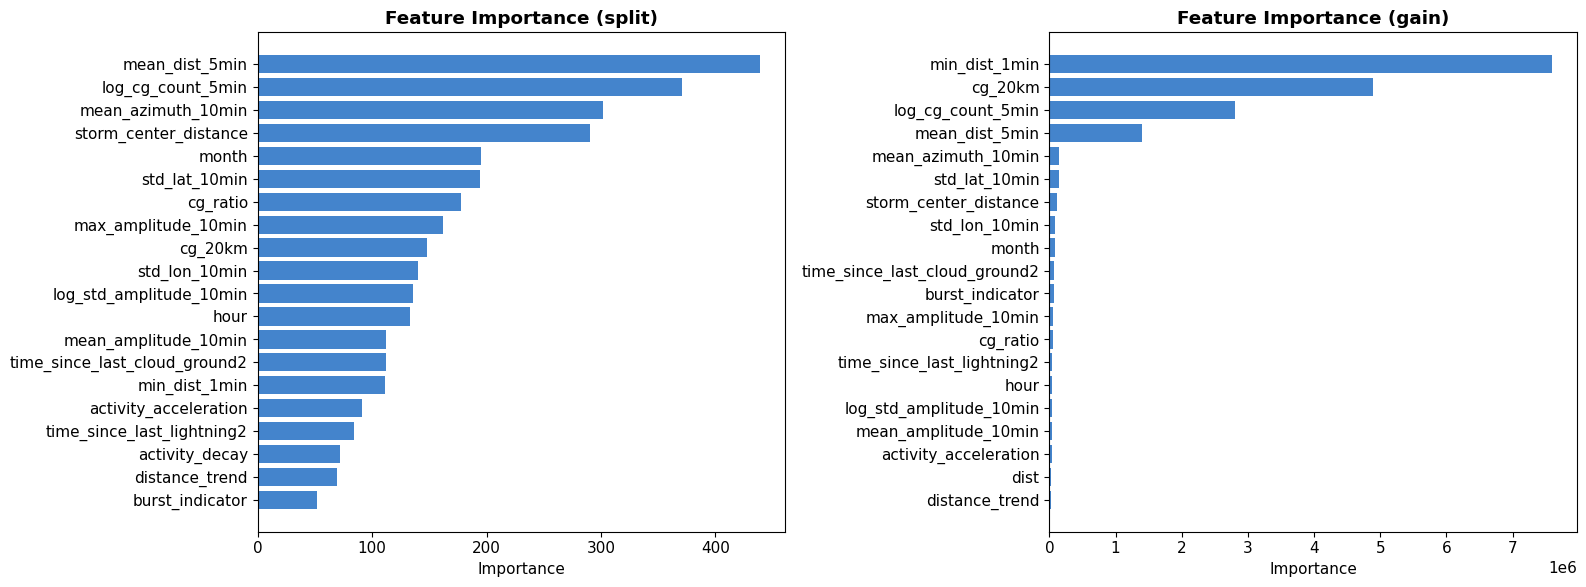

In [80]:
# ── 4. Feature importance ─────────────────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 4 — Feature Importance")
print("="*60)
######################################
model_tuned  = model_baseline
selected_features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, importance_type in zip(axes, ['split', 'gain']):
    importances = model_tuned.feature_importances_ if importance_type == 'split' \
                  else model_tuned.booster_.feature_importance(importance_type='gain')
    
    df_imp = (
        pd.DataFrame({'feature': selected_features, 'importance': importances})
        .sort_values('importance', ascending=True)
        .tail(20)
    )
    ax.barh(df_imp['feature'], df_imp['importance'], color='#1565C0', alpha=0.8)
    ax.set_title(f'Feature Importance ({importance_type})', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [83]:
# ── 5. Résumé ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RÉSUMÉ")
print("="*60)
print(f"  Observations train    : {len(X_train):,}")
print(f"  Observations val      : {len(X_val):,}")
print(f"  Observations test     : {len(X_test):,}")
print(f"  Features utilisées    : {len(features)}")
print(f"  Trials Optuna         : {len(study.trials)}")
print(f"  RMSE baseline         : {rmse_baseline:.4f}")
#print(f"  RMSE tuné             : {rmse_tuned:.4f}")
#print(f"  Gain                  : {(rmse_baseline - rmse_tuned) / rmse_baseline * 100:.1f}%")


RÉSUMÉ
  Observations train    : 391,070
  Observations val      : 38,300
  Observations test     : 77,664
  Features utilisées    : 63
  Trials Optuna         : 10
  RMSE baseline         : 1.2197


In [87]:
pred = np.exp(model_tuned.predict(X_test))-1
obs =  np.exp(y_test) -1
rmse   = np.sqrt(np.mean((obs- pred)**2))
rmse


np.float64(850.2506661628427)

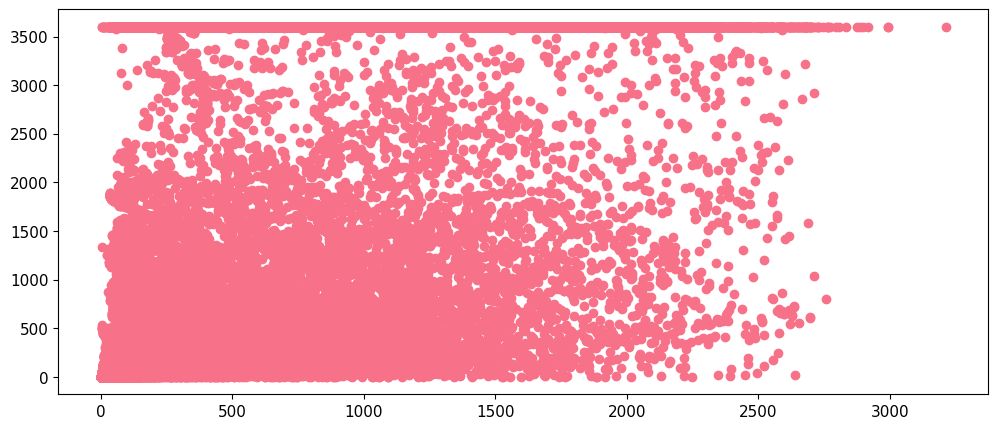

In [88]:
plt.scatter(pred,obs)

In [ ]:
pred[:20]

array([2.20720063e+04, 1.94974548e+04, 1.78739131e+04, 2.46691688e+01,
       1.14696130e+04, 1.49203256e+04, 5.05548599e+03, 5.81168029e+03,
       5.34718215e+03, 3.75697585e+03, 4.03413206e+03, 2.57423889e+03,
       1.87457431e+03, 1.94072289e+04, 1.24745558e+03, 1.68474004e+03,
       1.13861382e+03, 7.66286893e+02, 1.22280756e+03, 1.61694196e+01])

In [ ]:
fff

# LSTM

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# 0. PARAMÈTRES
# ══════════════════════════════════════════════════════════════
SEQ_LEN      = 5
TARGET_COL   = 'target_log_time'
BATCH_SIZE   = 32
EPOCHS       = 1
LR           = 1e-3
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Features par éclair — delta_t EN PREMIER, c'est crucial
SEQUENCE_FEATURES = [
    'time_since_last_cloud_ground',   # ← intervalle irrégulier encodé explicitement
] + [f for f in features if f not in [
    'time_since_last_cloud_ground'
]]

print(f"Device : {DEVICE}")
print(f"Features séquence ({len(SEQUENCE_FEATURES)}) : {SEQUENCE_FEATURES}")


Device : cpu
Features séquence (69) : ['time_since_last_cloud_ground', 'storm_direction_change', 'amplitude', 'min_dist_1min', 'cg_count_20min', 'azimuth_change', 'rate_5min', 'cg_ratio', 'hour', 'mean_dist_1min', 'mean_azimuth_10min', 'is_cloud_ground', 'delta_dist', 'mean_amplitude_1min', 'max_amplitude_1min', 'time_since_last_intra_cloud', 'count_30min', 'azimuth', 'max_amplitude_10min', 'amplitude_change', 'ic_count_20min', 'burst_indicator', 'count_5min', 'count_10min', 'storm_center_move', 'std_azimuth_10min', 'rate_trend', 'distance_trend', 'log_silence_time', 'rate_1min', 'count_20min', 'mean_azimuth_1min', 'mean_amplitude_10min', 'ic_count_10min', 'rate_10min', 'activity_acceleration', 'silence_30min', 'azimuth_diff', 'mean_dist_5min', 'month', 'cg_20km', 'alert_duration', 'std_lon_10min', 'storm_velocity', 'min_dist_5min', 'std_azimuth_1min', 'min_dist_10min', 'time_since_last_lightning', 'storm_center_distance', 'ic_count_5min', 'dist', 'std_lat_10min', 'cg_count_5min', 'std

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. CONSTRUCTION DES SÉQUENCES IRRÉGULIÈRES
# ══════════════════════════════════════════════════════════════
def build_irregular_sequences(df, feature_cols, target_col, seq_len,
                               group_cols=['airport']):
    """
    Construit les séquences en encodant explicitement les intervalles
    de temps irréguliers entre éclairs CG.
    
    Pour chaque éclair i, la séquence contient les seq_len éclairs
    précédents avec leurs delta_t réels.
    
    Returns:
        X_seq   : (N, seq_len, n_features)  — séquences
        X_mask  : (N, seq_len)              — masque padding (1=réel, 0=pad)
        y       : (N,)                      — cible
        meta    : DataFrame                 — airport, date pour évaluation
    """
    df = df.sort_values(group_cols + ['date']).reset_index(drop=True)
    n_feat = len(feature_cols)

    X_seq, X_mask, y_out, meta = [], [], [], []

    for airport, grp in df.groupby(group_cols):
        grp = grp.reset_index(drop=True)

        # Calcul delta_t réel intra-alerte (secondes)
        grp['delta_prev_cg_sec'] = (
            grp['date'].diff().dt.total_seconds().fillna(0)
        )

        features = grp[feature_cols].values.astype(np.float32)
        targets  = grp[target_col].values.astype(np.float32)

        for i in range(len(grp)):
            # Séquence des i derniers éclairs (contexte)
            if i == 0:
                seq  = np.zeros((seq_len, n_feat), dtype=np.float32)
                mask = np.zeros(seq_len, dtype=np.float32)
            elif i < seq_len:
                pad_len = seq_len - i
                seq  = np.vstack([
                    np.zeros((pad_len, n_feat), dtype=np.float32),
                    features[:i]
                ])
                mask = np.array([0]*pad_len + [1]*i, dtype=np.float32)
            else:
                seq  = features[i-seq_len:i]
                mask = np.ones(seq_len, dtype=np.float32)

            X_seq.append(seq)
            X_mask.append(mask)
            y_out.append(targets[i])
            meta.append({'airport': airport, 'date': grp.loc[i, 'date']})

    return (
        np.array(X_seq,  dtype=np.float32),
        np.array(X_mask, dtype=np.float32),
        np.array(y_out,  dtype=np.float32),
        pd.DataFrame(meta)
    )






Construction des séquences...


KeyError: 'airport'

In [ ]:
print("\nConstruction des séquences...")
df_model = df2.dropna(subset=[TARGET_COL] + SEQUENCE_FEATURES).copy()

X_seq, X_mask, y_all, meta = build_irregular_sequences(
    df_model, SEQUENCE_FEATURES, TARGET_COL, SEQ_LEN
)
print(f"  Séquences : {X_seq.shape}   (N, seq_len, n_features)")
print(f"  Masque    : {X_mask.shape}")
print(f"  Cible     : {y_all.shape}")


Construction des séquences...


KeyError: ['season_Automne', 'season_Hiver', 'season_Printemps', 'airport_Ajaccio', 'airport_Pise', 'airport_Bastia', 'airport_Biarritz', 'airport_Nantes']

In [ ]:

# ══════════════════════════════════════════════════════════════
# 2. SPLIT TEMPOREL & NORMALISATION
# ══════════════════════════════════════════════════════════════
cutoff_idx = int(len(meta) * 0.8)

X_tr,   X_te   = X_seq[:cutoff_idx],  X_seq[cutoff_idx:]
M_tr,   M_te   = X_mask[:cutoff_idx], X_mask[cutoff_idx:]
y_tr,   y_te   = y_all[:cutoff_idx],  y_all[cutoff_idx:]
meta_tr, meta_te = meta.iloc[:cutoff_idx], meta.iloc[cutoff_idx:]

# Normalisation — fit sur train uniquement
n_feat  = X_tr.shape[2]
scaler  = StandardScaler()
X_tr_n  = scaler.fit_transform(X_tr.reshape(-1, n_feat)).reshape(X_tr.shape)
X_te_n  = scaler.transform(X_te.reshape(-1, n_feat)).reshape(X_te.shape)

# Log-transform cible (distribution très asymétrique)
y_tr_log = np.log1p(y_tr)
y_te_log = np.log1p(y_te)

print(f"\nTrain : {len(X_tr):,}  |  Test : {len(X_te):,}")
print(f"Période train : {meta_tr['date'].min().date()} → {meta_tr['date'].max().date()}")
print(f"Période test  : {meta_te['date'].min().date()} → {meta_te['date'].max().date()}")



In [ ]:

# ══════════════════════════════════════════════════════════════
# 3. DATASET
# ══════════════════════════════════════════════════════════════
class LightningSequenceDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

train_loader = DataLoader(
    LightningSequenceDataset(X_tr_n, M_tr, y_tr_log),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
test_loader = DataLoader(
    LightningSequenceDataset(X_te_n, M_te, y_te_log),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)


# ══════════════════════════════════════════════════════════════
# 4. ARCHITECTURE LSTM IRREGULIER
# ══════════════════════════════════════════════════════════════
class IrregularLSTM(nn.Module):
    """
    LSTM adapté aux séries temporelles irrégulières.
    
    Clé : delta_t est la première feature de la séquence,
    ce qui permet au LSTM d'apprendre à pondérer les éclairs
    passés selon leur ancienneté réelle.
    
    Le masque de padding est utilisé pour ignorer les pas
    de temps artificiels (zéros) en début de séquence.
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden_size)

        # Tête de régression
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Tête Weibull (survie)
        self.head_alpha = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1), nn.Softplus()
        )
        self.head_beta = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1), nn.Softplus()
        )

    def forward(self, x, mask=None, mode='regression'):
        """
        x    : (batch, seq_len, input_size)
        mask : (batch, seq_len) — 1=éclair réel, 0=padding
        """
        lstm_out, _ = self.lstm(x)       # (batch, seq_len, hidden)

        # Masquage : on prend le dernier pas de temps RÉEL
        # (pas le dernier pad) grâce au masque
        if mask is not None:
            # Longueur réelle de chaque séquence
            lengths = mask.sum(dim=1).long().clamp(min=1)
            # Indice du dernier éclair réel
            last_idx = (lengths - 1).clamp(min=0)
            # Pour les séquences avec padding en début,
            # le dernier réel est à seq_len-1
            batch_idx = torch.arange(lstm_out.size(0), device=lstm_out.device)
            # On prend toujours le dernier pas (le plus récent)
            out = lstm_out[batch_idx, -1, :]
        else:
            out = lstm_out[:, -1, :]

        out = self.norm(self.dropout(out))

        if mode == 'regression':
            return self.head(out).squeeze(-1)

        elif mode == 'weibull':
            alpha = self.head_alpha(out).squeeze(-1) + 1e-6
            beta  = self.head_beta(out).squeeze(-1)  + 1e-6
            return alpha, beta


def weibull_nll_loss(alpha, beta, t, eps=1e-6):
    """Log-vraisemblance négative Weibull."""
    t = t.clamp(min=eps)
    return -(
        torch.log(beta + eps)
        - torch.log(alpha + eps)
        + (beta - 1) * torch.log(t / (alpha + eps) + eps)
        - (t / (alpha + eps)) ** beta
    ).mean()


# ══════════════════════════════════════════════════════════════
# 5. ENTRAÎNEMENT
# ══════════════════════════════════════════════════════════════
def train_lstm(mode='regression', hidden_size=128, num_layers=2,
               dropout=0.3, epochs=EPOCHS, lr=LR):

    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT LSTM — mode : {mode}")
    print(f"  hidden={hidden_size} | layers={num_layers} | dropout={dropout}")
    print(f"{'='*60}")

    model = IrregularLSTM(
        input_size=n_feat,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Paramètres : {n_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=False
    )
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val, best_state, patience_counter = np.inf, None, 0
    PATIENCE = 10

    for epoch in range(1, epochs + 1):

        # ── Train ──────────────────────────────────────────
        model.train()
        batch_losses = []
        for X_b, M_b, y_b in train_loader:
            X_b, M_b, y_b = X_b.to(DEVICE), M_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()

            if mode == 'regression':
                pred = model(X_b, M_b, mode='regression')
                loss = criterion(pred, y_b)
            else:
                alpha, beta = model(X_b, M_b, mode='weibull')
                t = torch.expm1(y_b).clamp(min=1e-6)
                loss = weibull_nll_loss(alpha, beta, t)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        # ── Validation ─────────────────────────────────────
        model.eval()
        val_batch = []
        with torch.no_grad():
            for X_b, M_b, y_b in test_loader:
                X_b, M_b, y_b = X_b.to(DEVICE), M_b.to(DEVICE), y_b.to(DEVICE)
                if mode == 'regression':
                    pred = model(X_b, M_b, mode='regression')
                    loss = criterion(pred, y_b)
                else:
                    alpha, beta = model(X_b, M_b, mode='weibull')
                    t = torch.expm1(y_b).clamp(min=1e-6)
                    loss = weibull_nll_loss(alpha, beta, t)
                val_batch.append(loss.item())

        val_loss = np.mean(val_batch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  ⏹  Early stopping à l'époque {epoch}")
                break

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:>3}/{epochs}  "
                  f"Train={train_loss:.4f}  Val={val_loss:.4f}  "
                  f"Best={best_val:.4f}  LR={optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)

    # Courbe d'apprentissage
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label='Train', color='#1565C0', linewidth=2)
    plt.plot(val_losses,   label='Validation', color='#F44336', linewidth=2)
    plt.xlabel('Époque')
    plt.ylabel('Loss')
    plt.title(f'Courbe apprentissage — LSTM {mode}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'/mnt/user-data/outputs/lstm_loss_{mode}.png', dpi=150)
    plt.show()

    return model, best_val

model_reg,     loss_reg     = train_lstm(mode='regression')
model_weibull, loss_weibull = train_lstm(mode='weibull')


# ══════════════════════════════════════════════════════════════
# 6. ÉVALUATION
# ══════════════════════════════════════════════════════════════
def evaluate(model, mode='regression'):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X_b, M_b, y_b in test_loader:
            X_b, M_b = X_b.to(DEVICE), M_b.to(DEVICE)
            if mode == 'regression':
                out = model(X_b, M_b, mode='regression').cpu().numpy()
                preds.append(out)
            else:
                alpha, beta = model(X_b, M_b, mode='weibull')
                # Médiane Weibull = alpha * log(2)^(1/beta)
                median_t = (alpha * torch.log(torch.tensor(2.0)) ** (1/beta))
                preds.append(np.log1p(median_t.cpu().numpy()))
            targets.append(y_b.numpy())

    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)

    # Dé-log pour RMSE en secondes
    pred_sec   = np.expm1(preds)
    target_sec = np.expm1(targets)
    rmse = np.sqrt(np.mean((pred_sec - target_sec)**2))
    mae  = np.mean(np.abs(pred_sec - target_sec))

    print(f"\n  RMSE : {rmse:.1f} sec  ({rmse/60:.1f} min)")
    print(f"  MAE  : {mae:.1f} sec  ({mae/60:.1f} min)")
    return preds, targets

print("\n── Régression ──")
pred_reg, tgt_reg = evaluate(model_reg, mode='regression')

print("\n── Weibull ──")
pred_wb,  tgt_wb  = evaluate(model_weibull, mode='weibull')


# ══════════════════════════════════════════════════════════════
# 7. PROBABILITÉ DE FIN D'ALERTE
# ══════════════════════════════════════════════════════════════
def predict_proba_end_alert(model_weibull, X_norm, M, T_minutes=30):
    """
    P(prochain éclair CG > T_minutes) = P(fin d'alerte dans T min)
    = exp(-(T/alpha)^beta)   [survie Weibull]
    
    Si cette proba est haute → l'orage est probablement fini → lever l'alerte
    """
    model_weibull.eval()
    T_sec = T_minutes * 60
    probas = []

    loader = DataLoader(
        list(zip(torch.tensor(X_norm, dtype=torch.float32),
                 torch.tensor(M, dtype=torch.float32))),
        batch_size=BATCH_SIZE
    )
    with torch.no_grad():
        for X_b, M_b in loader:
            X_b, M_b = X_b.to(DEVICE), M_b.to(DEVICE)
            alpha, beta = model_weibull(X_b, M_b, mode='weibull')
            # P(T_next > T) = survie Weibull
            surv = torch.exp(-((T_sec / (alpha + 1e-6)) ** beta))
            probas.append(surv.cpu().numpy())

    return np.concatenate(probas)

proba_fin = predict_proba_end_alert(model_weibull, X_te_n, M_te, T_minutes=30)

# Résumé opérationnel
seuils = [0.80, 0.85, 0.90, 0.95]
print("\n── Seuils opérationnels ──")
print(f"{'Seuil':>8} {'% alertes levées':>18}")
print("-" * 28)
for s in seuils:
    pct = (proba_fin >= s).mean() * 100
    print(f"  {s:.2f}         {pct:>8.1f}%")